### Select folder

In [252]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parents[0]
sys.path.insert(0, str(PROJECT_ROOT))

In [253]:
from PyQt6.QtWidgets import QApplication, QFileDialog
import sys

def select_folder_pyqt6():
    # Create application
    app = QApplication(sys.argv)

    # Open folder dialog
    folder_path = QFileDialog.getExistingDirectory(
        None,
        "Select a folder",
        ""
    )

    # Close QApplication
    app.exit()

    return folder_path

path = select_folder_pyqt6()
print(f"path: {path}")

path: X:/Anlagen/_lab31316-nlo/Inbox/experiment/202511_NLO_measurement_results/20260217_1438_quartz-3_d11_wedge


In [254]:
from shg_analysis import SHGDataAnalysis
from fitting_strategies.shoji1997 import Shoji1997WedgeStrategy
from crystaldatabase import CRYSTALS
from crystaldatabase import *

analysis = SHGDataAnalysis(path)
strategy = Shoji1997WedgeStrategy(analysis)
meta = analysis.meta
data = analysis.data

crystal = CRYSTALS[meta["material"]]()

### Modeling

薄い方を手前にするなら、xが小さい時分厚い側にスポットが来るので、wedge < 0とする。  
薄い方が奥なら、wedge > 0

In [255]:
wedge_deg = meta["thickness_info"]["wedge_angle_deg"]
wedge = np.deg2rad(wedge_deg)

fringe = strategy._maker_fringes(override={"wedge_deg":wedge_deg})

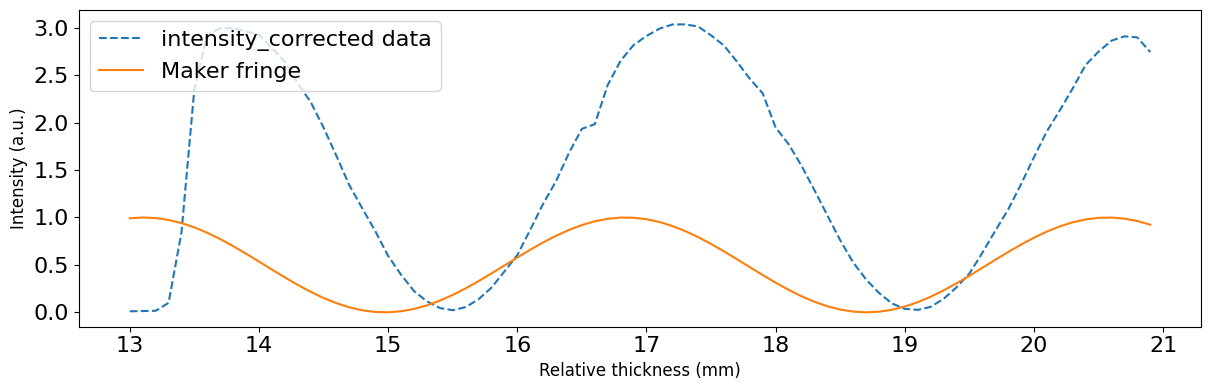

In [256]:
import matplotlib.pyplot as plt
import numpy as np

x = data["position"]
x = np.asarray(x)
intensity_corrected = data["intensity_corrected"]
intensity_corrected = np.asarray(intensity_corrected)

plt.rcParams['font.size'] = 10
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(x, intensity_corrected, label='intensity_corrected data', linestyle='--')
ax.plot(x, fringe, label='Maker fringe')
ax.set_xlabel('Relative thickness (mm)', fontsize=12)
ax.set_ylabel('Intensity (a.u.)', fontsize=12)
# ax.set_xlim(-20, 20)
# ax.set_ylim(0, 10)

fig.tight_layout()
ax.legend(loc='upper left')
plt.show()

### Check theoretical fringe without data

80


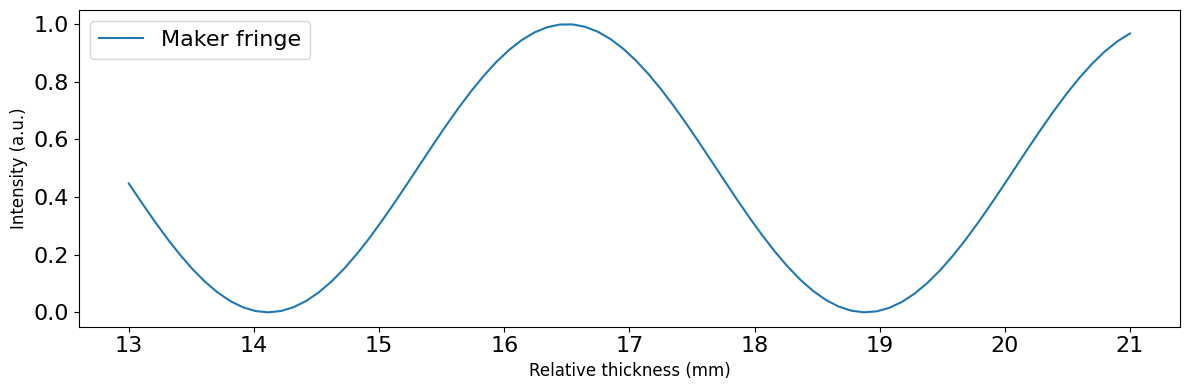

In [257]:
import pandas as pd
virtual_x = np.linspace(13, 21, 80)
virtual_data = pd.DataFrame()
virtual_data["position"] = virtual_x
print(np.size(virtual_data))

virtual_fringe = strategy._maker_fringes(override={"wedge_deg": 0.5, "data":virtual_data})

plt.rcParams['font.size'] = 10
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(virtual_x, virtual_fringe, label='Maker fringe')
ax.set_xlabel('Relative thickness (mm)', fontsize=12)
ax.set_ylabel('Intensity (a.u.)', fontsize=12)
# ax.set_xlim(-20, 20)
# ax.set_ylim(0, 10)

fig.tight_layout()
ax.legend(loc='upper left')
plt.show()

### Detect minima

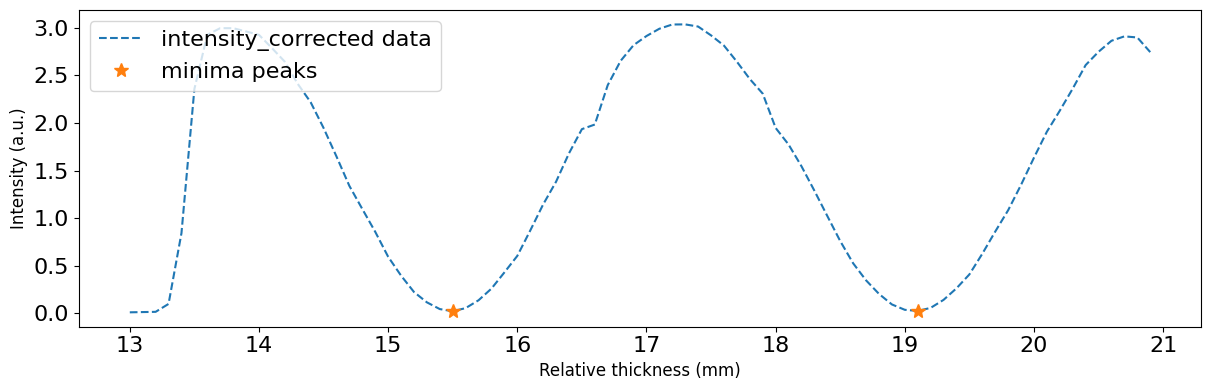

In [258]:
idx_min = strategy.detect_minima(x, intensity_corrected)
minima_x = x[idx_min]
minima_y = intensity_corrected[idx_min]

plt.rcParams['font.size'] = 10
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(x, intensity_corrected, label='intensity_corrected data', linestyle='--')
ax.plot(minima_x, minima_y, "*", ms=10, label='minima peaks')

ax.set_xlabel('Relative thickness (mm)', fontsize=12)
ax.set_ylabel('Intensity (a.u.)', fontsize=12)

# ax.set_xlim(-20, 20)
# ax.set_ylim(-0.1, 3.2)

fig.tight_layout()
ax.legend(loc='upper left')
plt.show()

In [259]:
Lc_list = []
for i in range(len(minima_x) - 1):
    Lc = 0.5 * (minima_x[i+1] - minima_x[i]) * np.tan(wedge)
    Lc_list.append(Lc)

Lc_measured = np.mean(np.asarray(Lc_list))

### Fit L

In [260]:
ft_ticks = 14
ft_labels = 18

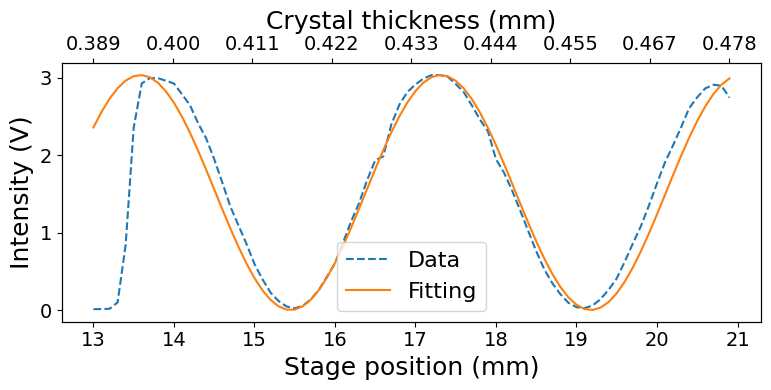

fitted L: 0.4457 (delta=-5.3)
measured L: 0.451
Fitted Lc: 20.83 um
Measured Lc: 20.11 um
peak amplitude: 3.0363636363636366


In [261]:
if meta["method"] == "rotation":
    pass
elif meta["method"] == "wedge":
    L_results, L_aux = strategy._fit_L()

    L_fit_mm = L_results["L_fit_mm"]
    L_fit_fringe, aux = strategy._maker_fringes(
        override={"L": L_fit_mm, "wedge_deg":wedge_deg},
        return_aux=True
        )
    
    thickness = aux["L_array"]
    Lc_th = aux["Lc"]
    amp = np.max(intensity_corrected)

    plt.rcParams['font.size'] = 10
    fig, ax = plt.subplots(figsize=(8, 4))

    ax.plot(x, intensity_corrected, label='Data', linestyle='--')
    ax.plot(x, amp * L_fit_fringe, label='Fitting')
    ax.set_xlabel('Stage position (mm)', fontsize=ft_labels)
    ax.set_ylabel('Intensity (V)', fontsize=ft_labels)
    ax.tick_params(axis="x", labelsize=ft_ticks)
    ax.tick_params(axis="y", labelsize=ft_ticks)
    # ax.set_xlim(-20, 20)
    # ax.set_ylim(0, 10)

    # ---- Top x-axis (crystal thickness) ----
    ax_top = ax.twiny()
    ax_top.set_xlim(ax.get_xlim())

    # Choose tick positions from stage axis
    n_ticks = 9
    x_ticks = np.linspace(x.min(), x.max(), n_ticks)

    # Interpolate thickness at those positions
    thickness_ticks = np.interp(x_ticks, x, thickness)

    ax_top.set_xticks(x_ticks)
    ax_top.tick_params(axis="x", labelsize=ft_ticks)
    ax_top.set_xticklabels([f"{t:.3f}" for t in thickness_ticks])
    ax_top.set_xlabel("Crystal thickness (mm)", fontsize=ft_labels)

    fig.tight_layout()
    ax.legend()
    # ax.legend(loc='upper left')
    plt.show()


    print(f"fitted L: {L_fit_mm:.4f} (delta={L_results["dL_um"]:.1f})")
    print(f"measured L: {meta["thickness_info"]["t_center_mm"]}")
    print(f"Fitted Lc: {Lc_th *1000:.2f} um")
    print(f"Measured Lc: {Lc_measured *1000:.2f} um")
    print(f"peak amplitude: {amp}")

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# ---- Plot style control (single variable) ----
ft = 16  # Change this to scale everything

plt.rcParams.update({
    "font.size": ft,
    "axes.titlesize": ft,
    "axes.labelsize": ft,
    "xtick.labelsize": ft,
    "ytick.labelsize": ft,
    "legend.fontsize": ft,
})

# ---- Angle axis ----


# ---- L settings ----
L0_mm = analysis.meta["thickness_info"]["t_center_mm"]  # <-- set your nominal L here [mm]
L_fit_mm = L0_mm
dL_um = 20.0   # +/- range [um]
dL_mm = dL_um / 1000.0

# ---- Vertical scale settings ----
A0 = np.max(intensity_corrected)        # Initial vertical scale
A_range = np.max(intensity_corrected) * 2.0


slider_dL = widgets.FloatSlider(
    value=0.0,
    min=-dL_um,
    max=+dL_um,
    step=dL_um / 300.0,
    description="ΔL (µm)",
    continuous_update=True,
    readout=True,
    readout_format=".1f",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="520px"),
)

slider_A = widgets.FloatSlider(
    value=A0,
    min=0,
    max=A_range,
    step=A_range / 300.0,
    description="Scale A",
    continuous_update=True,
    readout=True,
    readout_format=".2f",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="520px"),
)

btn_reset = widgets.Button(description="Reset", layout=widgets.Layout(width="120px"))

out = widgets.Output()

def redraw(dL_current_um: float, A: float):
    L_mm = L_fit_mm + dL_current_um / 1000.0
    delta_L = (L_mm - L0_mm) * 1000
    fringe_manual, aux_manual = strategy._maker_fringes(override={"L":L_mm, "wedge_deg":wedge_deg}, return_aux=True)
    fringe_manual = A * fringe_manual

    thickness_manual = aux_manual["L_array"]

    with out:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(8, 4))
        # ax.plot(x, intensity_corrected, "*", color="green", label='Data')
        # ax.plot(x, fringe_manual, lw=2, linestyle="-", color="orange", label="Fitting")
        ax.plot(x, intensity_corrected, "*", label='Data')
        ax.plot(x, fringe_manual, lw=2, linestyle="-", label="Fitting")
        # ax.set_title("Wedge Maker fringe")
        ax.set_xlabel('Stage position (mm)', fontsize=ft_labels)
        ax.set_ylabel('Intensity (V)', fontsize=ft_labels)
        ax.tick_params(axis="x", labelsize=ft_ticks)
        ax.tick_params(axis="y", labelsize=ft_ticks)
        # ax.set_xlim(-20, 20)
        ax.set_ylim(0, amp*1.5)

        # ---- Top x-axis (crystal thickness) ----
        ax_top = ax.twiny()
        ax_top.set_xlim(ax.get_xlim())

        # Choose tick positions from stage axis
        n_ticks = 9
        x_ticks = np.linspace(x.min(), x.max(), n_ticks)

        # Interpolate thickness at those positions
        thickness_ticks = np.interp(x_ticks, x, thickness_manual)

        ax_top.set_xticks(x_ticks)
        ax_top.tick_params(axis="x", labelsize=ft_ticks)
        ax_top.set_xticklabels([f"{t:.3f}" for t in thickness_ticks])
        ax_top.set_xlabel("Crystal thickness (mm)", fontsize=ft_labels)

        fig.tight_layout()
        ax.legend()

        ax.grid(True)
        ax.text(
            0.02, 0.95,
            f"L = {L_mm:.4f} mm  (ΔL = {delta_L:+.1f} µm)\nPeak ={A:.2f}",
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize=ft
        )
        # ax.legend(loc="upper right")
        ax.legend(fontsize=ft)
        plt.show()

def _on_slider_change(_=None):
    redraw(slider_dL.value, slider_A.value)


def _on_reset(_):
    slider_dL.value = 0.0
    slider_A.value = A0

slider_dL.observe(lambda ch: _on_slider_change(), names="value")
slider_A.observe(lambda ch: _on_slider_change(), names="value")
btn_reset.on_click(_on_reset)

display(widgets.VBox([
    widgets.HBox([slider_dL, btn_reset]),
    slider_A,
    out
]))

# Initial draw
redraw(slider_dL.value, slider_A.value)